# Transaction Costs Modelling

## Overview
This Jupyter Notebook models transaction costs for the regime-switching tactical allocation strategies across all 5 baskets. It implements a two-layer cost structure: (1) stock-level turnover costs from monthly rebalancing within offensive/defensive baskets, and (2) inter-basket switching costs from regime-driven allocation changes between offensive and defensive strategies. The notebook uses Frazzini et al. (2012) time-varying transaction cost estimates and validates the economic viability of the strategies after costs.

## Key Features
- **Two-Layer Cost Structure**: Stock-level turnover (June rebalancing) + Inter-basket switching (Offensive ↔ Defensive).
- **Time-Varying Costs**: Pre-1980: 50 bps, 1980-1999: 25 bps, 2000-2009: 10 bps, 2010+: 10 bps (one-way, based on Frazzini et al. 2012).
- **Annual Rebalancing**: Costs applied only in June (annual formation date), zero costs in other months (Fama-French convention).
- **Basket-Specific Analysis**: Separate cost calculations for Basket 1 (Economic Classification) and Baskets 2-5 (Beta-based allocations with dynamic signal selection).
- **Stress Testing**: Sensitivity analysis with 1.5x, 2x, 3x, 5x cost multipliers to assess strategy robustness under adverse market conditions.
- **Export Format**: Monthly time-series files (parquet) ready for integration in Notebook 11_1 (net-of-costs performance analysis).

## Methodology

### Layer 1: Stock-Level Transaction Costs
1. Load individual signal turnovers (`turnover_high_ew`, `turnover_low_ew`) from all 25 unique fundamental signals.
2. **Basket 1 (Economic)**: Aggregate 9 offensive signals (P10 leg) and 16 defensive signals (P1/P10 legs) using equal-weight averaging.
3. **Baskets 2-5 (Beta-based)**: Load monthly allocation matrices, map selected signals to their baseline legs (P10/P1), compute equal-weight turnover across active signals for HIGH_BETA and LOW_BETA baskets.
4. Apply Frazzini time-varying costs: `cost_monthly = 2 * turnover * cost_bps / 10000` (two-way costs).
5. Set `cost_monthly = 0` for non-June months (annual rebalancing assumption).

### Layer 2: Inter-Basket Switching Costs
1. For Baskets 2-5: Load allocation matrices with binary HIGH_BETA/LOW_BETA assignments per signal.
2. Calculate monthly allocation switches: `switches[t] = |allocation[t] - allocation[t-1]|`.
3. Aggregate across signals: `turnover_inter = mean(switches)`.
4. Apply same Frazzini cost schedule as Layer 1.
5. Map inter-basket costs to both offensive and defensive strategies (costs incurred when regime prediction changes).

### Total Transaction Costs
- **By Basket**: `Total TC = Stock-Level TC + Inter-Basket TC`.
- **By Strategy**: Costs mapped to `strategy` dimension (Offensive/Defensive for Basket 1, High_Beta/Low_Beta for Baskets 2-5) to enable strategy-level net return calculations.
- **Time-Series Export**: Monthly panel data `[date, basket, strategy, stock_tc_pct, inter_tc_pct, total_tc_pct]`.

## Dependencies
- Libraries: pandas, numpy, matplotlib, seaborn, pathlib.
- Data:
  - Signal turnovers: `data/portfolios/{factor}_signal.parquet` (528 files, one per signal).
  - Basket allocations: `data/ml_data/baskets/allocations/basket_{2-5}_allocations.parquet`.
  - Configurations: Offensive/Defensive signal lists (Basket 1), FEATURES_BASELINE (Baskets 2-5).
- Environment: macOS with VS Code, Python 3.x.

## Usage
1. **Cell 1-2**: Load configurations and individual signal turnovers (validate all 25 signals present).
2. **Cell 3**: Compute Basket 1 turnovers (equal-weight aggregation across offensive/defensive signals).
3. **Cell 4**: Compute Baskets 2-5 turnovers (allocation-weighted aggregation across dynamic signal selection).
4. **Cell 5**: Merge all baskets into single dataset, validate data completeness.
5. **Cell 6**: Apply Frazzini time-varying costs, set June-only rebalancing flag.
6. **Cell 7**: Generate comprehensive statistics (turnover, costs, annualized metrics) by basket and signal.
7. **Cell 8**: Run validation checks (non-negativity, rebalancing logic, cost magnitude).
8. **Cell A-B**: Compute inter-basket switching costs (standalone analysis), merge with stock-level costs.
9. **Cell C**: Export two files:
   - `tc_summary_by_basket.parquet`: Static summary (5 baskets × 5 columns).
   - `tc_timeseries_monthly.parquet`: Monthly panel (date × basket × strategy, 3 cost columns).
10. **Cell D**: Visualization (stacked bar charts, time-series evolution, cost distribution histograms).

## Output Files
- **data/ml_data/transaction_costs/tc_summary_by_basket.parquet**: Summary table (5 rows × 5 columns).
  - Columns: `Basket`, `basket_name`, `Stock-Level (%)`, `Inter-Basket (%)`, `Total (%)`.
  - Example: basket_1 → 0.35% stock + 0.02% inter = 0.37% total.

- **data/ml_data/transaction_costs/tc_timeseries_monthly.parquet**: Monthly time-series (66,000+ rows).
  - Columns: `date`, `basket`, `strategy`, `stock_tc_pct`, `inter_tc_pct`, `total_tc_pct`.
  - Format: Merge-ready for Notebook 11_1 on `[date, basket, strategy]`.
  - Non-June months: All costs = 0 (Fama-French convention for annual rebalancing).


# Cell 1: Configuration and Imports

Load dependencies and define configurations.

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

BASE_DIR = Path('/Users/jey/Desktop/Quant/V2')
PORTFOLIOS_DIR = BASE_DIR / 'data' / 'portfolios'
BASKETS_DIR = BASE_DIR / 'data' / 'ml_data' / 'baskets'
OUTPUT_DIR = BASE_DIR / 'data' / 'transaction_costs'
OUTPUT_DIR.mkdir(exist_ok=True, parents=True)

OFFENSIVE_CONFIG = {
    'sales_growth': 'P10',
    'asset_growth': 'P10',
    'investment_capex': 'P10',
    'capex_growth': 'P10',
    'asset_turnover': 'P10',
    'change_asset_turnover': 'P10',
    'receivables_turnover': 'P10',
    'cash_productivity': 'P10',
    'operating_leverage': 'P10'
}

DEFENSIVE_CONFIG = {
    'gross_profitability': 'P10',
    'operating_profitability': 'P10',
    'return_on_assets': 'P10',
    'roic': 'P10',
    'change_profit_margin': 'P10',
    'cash_cushion': 'P10',
    'debt_capacity': 'P10',
    'change_current_ratio': 'P10',
    'working_capital_accruals': 'P1',
    'sales_receivables_gap': 'P10',
    'net_share_issues': 'P1',
    'book_leverage': 'P1',
    'depreciation_to_ppe': 'P1',
    'change_depreciation': 'P1',
    'tax_income_ratio': 'P10',
    'capex_inventory_growth': 'P1'
}

FEATURES_BASELINE = {
    'gross_profitability': 'P10',
    'operating_profitability': 'P10',
    'return_on_assets': 'P10',
    'change_asset_turnover': 'P10',
    'change_profit_margin': 'P10',
    'roic': 'P10',
    'asset_growth': 'P1',
    'investment_capex': 'P1',
    'capex_inventory_growth': 'P1',
    'net_share_issues': 'P1',
    'capex_growth': 'P1',
    'sales_growth': 'P1',
    'working_capital_accruals': 'P1',
    'sales_receivables_gap': 'P10',
    'receivables_turnover': 'P10',
    'operating_leverage': 'P10',
    'cash_cushion': 'P10',
    'debt_capacity': 'P10',
    'book_leverage': 'P1',
    'change_current_ratio': 'P10',
    'asset_turnover': 'P10',
    'cash_productivity': 'P10',
    'depreciation_to_ppe': 'P1',
    'change_depreciation': 'P1',
    'tax_income_ratio': 'P10'
}

ANNUAL_REBALANCE_MONTH = 6

print('Configuration loaded')
print(f'Basket 1 - Offensive signals: {len(OFFENSIVE_CONFIG)}')
print(f'Basket 1 - Defensive signals: {len(DEFENSIVE_CONFIG)}')
print(f'Baskets 2-5 - Beta signals: {len(FEATURES_BASELINE)}')
print(f'Rebalancing month: {ANNUAL_REBALANCE_MONTH} (June)')

Configuration loaded
Basket 1 - Offensive signals: 9
Basket 1 - Defensive signals: 16
Baskets 2-5 - Beta signals: 25
Rebalancing month: 6 (June)


# Cell 2: Load Individual Signal Turnovers

Load turnover_high_ew and turnover_low_ew from all unique signals.

In [2]:
all_factors = set(
    list(OFFENSIVE_CONFIG.keys()) + 
    list(DEFENSIVE_CONFIG.keys()) + 
    list(FEATURES_BASELINE.keys())
)

print(f'Total unique signals: {len(all_factors)}')

signal_turnovers = {}
missing_signals = []

for factor in all_factors:
    signal_path = PORTFOLIOS_DIR / f'{factor}_signal.parquet'
    
    if signal_path.exists():
        df = pd.read_parquet(signal_path)
        
        required_cols = ['date', 'turnover_high_ew', 'turnover_low_ew']
        assert all(col in df.columns for col in required_cols), f'{factor}: missing turnover columns'
        
        df_turn = df[required_cols].set_index('date')
        signal_turnovers[factor] = df_turn
        
        print(f'{factor}: {df_turn.shape[0]} months')
    else:
        missing_signals.append(factor)
        print(f'{factor}: FILE NOT FOUND')

print(f'\nLoaded: {len(signal_turnovers)}/{len(all_factors)} signals')

if missing_signals:
    raise FileNotFoundError(f'Missing {len(missing_signals)} files: {missing_signals}')

Total unique signals: 25
receivables_turnover: 738 months
asset_growth: 738 months
working_capital_accruals: 738 months
change_profit_margin: 738 months
operating_leverage: 738 months
return_on_assets: 738 months
tax_income_ratio: 738 months
book_leverage: 726 months
capex_inventory_growth: 738 months
roic: 738 months
sales_growth: 738 months
gross_profitability: 738 months
change_asset_turnover: 738 months
depreciation_to_ppe: 738 months
cash_productivity: 738 months
asset_turnover: 738 months
operating_profitability: 738 months
cash_cushion: 738 months
capex_growth: 738 months
investment_capex: 738 months
debt_capacity: 738 months
change_current_ratio: 738 months
change_depreciation: 738 months
sales_receivables_gap: 738 months
net_share_issues: 738 months

Loaded: 25/25 signals


# Cell 3: Basket 1 - Economic Classification Turnovers

Map Offensive and Defensive configs to individual signal turnovers.

In [3]:
def compute_basket_turnover(config, signal_turnovers):
    """
    Compute Equal-Weight aggregate turnover for a basket.
    
    Args:
        config: Dict {factor: 'P10' or 'P1'}
        signal_turnovers: Dict {factor: DataFrame with turnover_high_ew, turnover_low_ew}
    
    Returns:
        pd.Series: Aggregated turnover (Equal-Weight)
    """
    turnover_series = []
    
    for factor, leg in config.items():
        df = signal_turnovers[factor]
        
        if leg == 'P10':
            turnover_series.append(df['turnover_high_ew'])
        elif leg == 'P1':
            turnover_series.append(df['turnover_low_ew'])
        else:
            raise ValueError(f'Invalid leg: {leg}')
    
    return pd.concat(turnover_series, axis=1).mean(axis=1)

turnover_offensive = compute_basket_turnover(OFFENSIVE_CONFIG, signal_turnovers)
turnover_defensive = compute_basket_turnover(DEFENSIVE_CONFIG, signal_turnovers)

print('Basket 1 - Economic Classification:')
print(f'  Offensive: mean={turnover_offensive.mean():.4f}, median={turnover_offensive.median():.4f}')
print(f'  Defensive: mean={turnover_defensive.mean():.4f}, median={turnover_defensive.median():.4f}')

df_basket_1 = pd.DataFrame({
    'date': turnover_offensive.index,
    'basket': 'basket_1',
    'signal': ['Offensive'] * len(turnover_offensive)
}).assign(turnover_ew=turnover_offensive.values)

df_basket_1 = pd.concat([
    df_basket_1,
    pd.DataFrame({
        'date': turnover_defensive.index,
        'basket': 'basket_1',
        'signal': 'Defensive',
        'turnover_ew': turnover_defensive.values
    })
], ignore_index=True)

print(f'\nBasket 1 dataset: {df_basket_1.shape[0]} observations')

Basket 1 - Economic Classification:
  Offensive: mean=0.8090, median=0.5446
  Defensive: mean=0.7707, median=0.5847

Basket 1 dataset: 1476 observations


# Cell 4: Baskets 2-5 - Load Allocations and Compute Turnovers

Load monthly allocations from basket files, map to individual signal turnovers.

In [4]:
def compute_beta_basket_turnovers(basket_name, alloc_file, signal_turnovers, features_baseline):
    """
    Compute turnovers for beta-based baskets using allocations.
    
    Args:
        basket_name: 'basket_2', 'basket_3', etc.
        alloc_file: Path to allocations parquet
        signal_turnovers: Dict of signal turnover DataFrames
        features_baseline: Config dict {factor: 'P10' or 'P1'}
    
    Returns:
        pd.DataFrame: Long format (date, basket, signal, turnover_ew)
    """
    allocations = pd.read_parquet(alloc_file)
    
    high_beta_alloc = allocations['HIGH_BETA']
    low_beta_alloc = allocations['LOW_BETA']
    
    records = []
    
    for date in allocations.index:
        high_factors = high_beta_alloc.loc[date][high_beta_alloc.loc[date] == 1].index.tolist()
        low_factors = low_beta_alloc.loc[date][low_beta_alloc.loc[date] == 1].index.tolist()
        
        high_turnovers = []
        for factor in high_factors:
            if factor in signal_turnovers and factor in features_baseline:
                leg = features_baseline[factor]
                df = signal_turnovers[factor]
                
                if date in df.index:
                    if leg == 'P10':
                        high_turnovers.append(df.loc[date, 'turnover_high_ew'])
                    else:
                        high_turnovers.append(df.loc[date, 'turnover_low_ew'])
        
        low_turnovers = []
        for factor in low_factors:
            if factor in signal_turnovers and factor in features_baseline:
                leg = features_baseline[factor]
                df = signal_turnovers[factor]
                
                if date in df.index:
                    if leg == 'P10':
                        low_turnovers.append(df.loc[date, 'turnover_high_ew'])
                    else:
                        low_turnovers.append(df.loc[date, 'turnover_low_ew'])
        
        if high_turnovers:
            records.append({
                'date': date,
                'basket': basket_name,
                'signal': 'High_Beta',
                'turnover_ew': np.mean(high_turnovers)
            })
        
        if low_turnovers:
            records.append({
                'date': date,
                'basket': basket_name,
                'signal': 'Low_Beta',
                'turnover_ew': np.mean(low_turnovers)
            })
    
    return pd.DataFrame(records)

beta_baskets_config = [
    ('basket_2', 'basket_2_allocations.parquet'),
    ('basket_3', 'basket_3_allocations.parquet'),
    ('basket_4', 'basket_4_allocations.parquet'),
    ('basket_5', 'basket_5_allocations.parquet')
]

df_beta_baskets = []

for basket_name, alloc_filename in beta_baskets_config:
    alloc_path = BASKETS_DIR / 'allocations' / alloc_filename
    
    if not alloc_path.exists():
        print(f'{basket_name}: Allocation file not found')
        continue
    
    df_basket = compute_beta_basket_turnovers(
        basket_name,
        alloc_path,
        signal_turnovers,
        FEATURES_BASELINE
    )
    
    df_beta_baskets.append(df_basket)
    print(f'{basket_name}: {df_basket.shape[0]} observations')

df_beta_combined = pd.concat(df_beta_baskets, ignore_index=True)

print(f'\nBeta baskets combined: {df_beta_combined.shape[0]} observations')

basket_2: 1344 observations
basket_3: 1344 observations
basket_4: 1344 observations
basket_5: 1462 observations

Beta baskets combined: 5494 observations


# Cell 5: Combine All Baskets

Merge all baskets into single dataset.

In [5]:
df_turnover_all = pd.concat([df_basket_1, df_beta_combined], ignore_index=True)

print(f'Combined dataset: {df_turnover_all.shape[0]} observations')
print(f'Unique baskets: {df_turnover_all["basket"].nunique()}')
print(f'Unique signals: {df_turnover_all["signal"].nunique()}')
print(f'Date range: {df_turnover_all["date"].min()} to {df_turnover_all["date"].max()}')

print('\nSignal counts by basket:')
print(df_turnover_all.groupby(['basket', 'signal']).size().unstack(fill_value=0))

print('\nTurnover statistics by signal:')
print(df_turnover_all.groupby('signal')['turnover_ew'].describe().round(4))

Combined dataset: 6970 observations
Unique baskets: 5
Unique signals: 4
Date range: 1963-07-31 00:00:00 to 2024-12-31 00:00:00

Signal counts by basket:
signal    Defensive  High_Beta  Low_Beta  Offensive
basket                                             
basket_1        738          0         0        738
basket_2          0        672       672          0
basket_3          0        672       672          0
basket_4          0        672       672          0
basket_5          0        731       731          0

Turnover statistics by signal:
            count    mean     std  min     25%     50%     75%      max
signal                                                                 
Defensive   738.0  0.7707  0.8766  0.0  0.1163  0.5847  1.0672   7.6186
High_Beta  2747.0  0.9308  1.0433  0.0  0.1938  0.7033  1.2925  10.2061
Low_Beta   2747.0  0.8071  0.8825  0.0  0.1572  0.5966  1.1365   7.5700
Offensive   738.0  0.8090  1.0565  0.0  0.0000  0.5446  1.1434   8.0660


# Cell 6: Apply Time-Varying Transaction Costs

Frazzini et al. (2012) cost structure. Apply only in June.

In [6]:
def get_frazzini_cost_bps(date):
    """
    One-way transaction cost in basis points.
    Based on Frazzini et al. (2012).
    
    Pre-1980: 100 bps
    1980-1999: 50 bps
    2000-2009: 30 bps
    2010+: 20 bps
    """
    year = date.year
    
    if year < 1980:
        return 50.0
    elif year < 2000:
        return 25.0
    elif year < 2010:
        return 10.0
    else:
        return 10.0

df_turnover_all['cost_bps'] = df_turnover_all['date'].apply(get_frazzini_cost_bps)

df_turnover_all['is_rebalance_month'] = df_turnover_all['date'].dt.month == ANNUAL_REBALANCE_MONTH

df_turnover_all['cost_monthly'] = np.where(
    df_turnover_all['is_rebalance_month'],
    2 * df_turnover_all['turnover_ew'] * df_turnover_all['cost_bps'] / 10000.0,
    0.0
)

print('Transaction cost application:')
print(f"Total observations: {df_turnover_all.shape[0]}")
print(f"Rebalance months (June): {df_turnover_all['is_rebalance_month'].sum()}")
print(f"Non-rebalance months: {(~df_turnover_all['is_rebalance_month']).sum()}")

df_rebalance = df_turnover_all[df_turnover_all['is_rebalance_month']]
print(f'\nRebalance month statistics:')
print(f"Mean turnover: {df_rebalance['turnover_ew'].mean():.4f}")
print(f"Mean cost (bps): {df_rebalance['cost_bps'].mean():.2f}")
print(f"Mean cost (return impact): {df_rebalance['cost_monthly'].mean():.6f}")

print('\nSample June costs:')
print(df_turnover_all[df_turnover_all['is_rebalance_month']].head(10))

Transaction cost application:
Total observations: 6970
Rebalance months (June): 580
Non-rebalance months: 6390

Rebalance month statistics:
Mean turnover: 1.0493
Mean cost (bps): 24.14
Mean cost (return impact): 0.005237

Sample June costs:
          date    basket     signal  turnover_ew  cost_bps  \
11  1964-06-30  basket_1  Offensive     0.000000      50.0   
23  1965-06-30  basket_1  Offensive     0.000000      50.0   
35  1966-06-30  basket_1  Offensive     0.000000      50.0   
47  1967-06-30  basket_1  Offensive     0.000000      50.0   
59  1968-06-28  basket_1  Offensive     0.000000      50.0   
71  1969-06-30  basket_1  Offensive     0.000000      50.0   
83  1970-06-30  basket_1  Offensive     2.368694      50.0   
95  1971-06-30  basket_1  Offensive     0.000000      50.0   
107 1972-06-30  basket_1  Offensive     2.070563      50.0   
119 1973-06-29  basket_1  Offensive     1.794595      50.0   

     is_rebalance_month  cost_monthly  
11                 True      0.00000

# Cell 7: Comprehensive Statistics by Basket and Signal

Detailed breakdown of turnovers and costs for each basket.

In [7]:
print('='*100)
print('COMPREHENSIVE STATISTICS BY BASKET AND SIGNAL')
print('='*100)

print('\n1. Turnover Statistics (All Months):')
print('-'*100)
turnover_stats = df_turnover_all.groupby(['basket', 'signal'])['turnover_ew'].agg([
    ('count', 'count'),
    ('mean', 'mean'),
    ('std', 'std'),
    ('min', 'min'),
    ('25%', lambda x: x.quantile(0.25)),
    ('median', 'median'),
    ('75%', lambda x: x.quantile(0.75)),
    ('max', 'max')
]).round(4)
print(turnover_stats)

print('\n2. Transaction Costs Statistics (June Only):')
print('-'*100)
df_june = df_turnover_all[df_turnover_all['is_rebalance_month']]
cost_stats = df_june.groupby(['basket', 'signal'])['cost_monthly'].agg([
    ('count', 'count'),
    ('mean', 'mean'),
    ('std', 'std'),
    ('min', 'min'),
    ('median', 'median'),
    ('max', 'max')
]).round(6)
print(cost_stats)

print('\n3. Annualized Turnover (June Only):')
print('-'*100)
annualized_turnover = df_june.groupby(['basket', 'signal'])['turnover_ew'].agg([
    ('mean_monthly', 'mean'),
    ('mean_annualized', lambda x: x.mean() * 12)
]).round(4)
print(annualized_turnover)

print('\n4. Cost Distribution by Period:')
print('-'*100)
df_june_copy = df_june.copy()
df_june_copy['period'] = pd.cut(
    df_june_copy['date'].dt.year,
    bins=[0, 1980, 2000, 2010, 2100],
    labels=['Pre-1980 (100bps)', '1980-1999 (50bps)', '2000-2009 (30bps)', '2010+ (20bps)']
)
period_stats = df_june_copy.groupby(['basket', 'signal', 'period'])['cost_monthly'].agg([
    ('count', 'count'),
    ('mean', 'mean')
]).round(6)
print(period_stats)

print('\n5. Summary by Basket (Across All Signals):')
print('-'*100)
basket_summary = df_turnover_all.groupby('basket').agg({
    'turnover_ew': ['count', 'mean', 'std'],
    'cost_monthly': ['mean', 'sum']
}).round(6)
basket_summary.columns = ['_'.join(col).strip() for col in basket_summary.columns.values]
print(basket_summary)

print('\n6. Overall Statistics (All Baskets Combined):')
print('-'*100)
print(f"Total observations: {df_turnover_all.shape[0]}")
print(f"Total June observations: {df_june.shape[0]}")
print(f"Mean turnover (all months): {df_turnover_all['turnover_ew'].mean():.4f}")
print(f"Mean turnover (June only): {df_june['turnover_ew'].mean():.4f}")
print(f"Mean cost (all months): {df_turnover_all['cost_monthly'].mean():.6f}")
print(f"Mean cost (June only): {df_june['cost_monthly'].mean():.6f}")
print(f"Total cost (sum across all): {df_turnover_all['cost_monthly'].sum():.6f}")

print('\n' + '='*100)

COMPREHENSIVE STATISTICS BY BASKET AND SIGNAL

1. Turnover Statistics (All Months):
----------------------------------------------------------------------------------------------------
                    count    mean     std  min     25%  median     75%  \
basket   signal                                                          
basket_1 Defensive    738  0.7707  0.8766  0.0  0.1163  0.5847  1.0672   
         Offensive    738  0.8090  1.0565  0.0  0.0000  0.5446  1.1434   
basket_2 High_Beta    672  0.9283  1.0160  0.0  0.2364  0.7277  1.2953   
         Low_Beta     672  0.8466  0.9047  0.0  0.1938  0.6231  1.2006   
basket_3 High_Beta    672  0.9520  1.0613  0.0  0.2356  0.7030  1.2933   
         Low_Beta     672  0.8224  0.8787  0.0  0.2193  0.5945  1.1782   
basket_4 High_Beta    672  0.9666  1.0689  0.0  0.2311  0.7251  1.3130   
         Low_Beta     672  0.8016  0.8574  0.0  0.1736  0.6202  1.1123   
basket_5 High_Beta    731  0.8808  1.0276  0.0  0.0000  0.6440  1.2416   
 

# Cell 8: Validation

Unit tests and integrity checks.

In [8]:
print('=== Validation Report ===')

print('\n1. Non-negativity checks:')
assert (df_turnover_all['turnover_ew'] >= 0).all(), 'FAILED: Negative turnover'
print('   PASS: All turnovers non-negative')

assert (df_turnover_all['cost_bps'] > 0).all(), 'FAILED: Non-positive cost_bps'
print('   PASS: All cost_bps positive')

assert (df_turnover_all['cost_monthly'] >= 0).all(), 'FAILED: Negative cost_monthly'
print('   PASS: All cost_monthly non-negative')

print('\n2. Rebalancing logic checks:')
non_rebalance_costs = df_turnover_all[~df_turnover_all['is_rebalance_month']]['cost_monthly']
assert (non_rebalance_costs == 0).all(), 'FAILED: Non-zero costs in non-rebalance months'
print('   PASS: Costs zero in non-rebalance months')

rebalance_costs = df_turnover_all[df_turnover_all['is_rebalance_month']]['cost_monthly']
nonzero_rebalance = (rebalance_costs > 0).sum()
print(f'   INFO: {nonzero_rebalance}/{len(rebalance_costs)} rebalance months have non-zero costs')

print('\n3. Data completeness checks:')
assert df_turnover_all['date'].notna().all(), 'FAILED: Missing dates'
print('   PASS: No missing dates')

assert df_turnover_all['basket'].notna().all(), 'FAILED: Missing basket identifiers'
print('   PASS: No missing basket identifiers')

assert df_turnover_all['signal'].notna().all(), 'FAILED: Missing signal identifiers'
print('   PASS: No missing signal identifiers')

print('\n4. Cost magnitude checks:')
max_cost = df_rebalance['cost_monthly'].max()
mean_cost = df_rebalance['cost_monthly'].mean()

assert max_cost < 0.10, f'FAILED: Unrealistic cost ({max_cost:.4f})'
print(f'   PASS: Max cost within range ({max_cost:.6f})')
print(f'   INFO: Mean rebalance cost: {mean_cost:.6f}')

print('\n=== All Validations Passed ===')

=== Validation Report ===

1. Non-negativity checks:
   PASS: All turnovers non-negative
   PASS: All cost_bps positive
   PASS: All cost_monthly non-negative

2. Rebalancing logic checks:
   PASS: Costs zero in non-rebalance months
   INFO: 507/580 rebalance months have non-zero costs

3. Data completeness checks:
   PASS: No missing dates
   PASS: No missing basket identifiers
   PASS: No missing signal identifiers

4. Cost magnitude checks:
   PASS: Max cost within range (0.047004)
   INFO: Mean rebalance cost: 0.005237

=== All Validations Passed ===


In [9]:
print('='*100)
print('COMPREHENSIVE STATISTICS BY BASKET AND SIGNAL')
print('='*100)

# 1. Turnover Statistics (All Months)
print('\n1. TURNOVER STATISTICS (ALL MONTHS):')
print('-'*100)
turnover_stats = df_turnover_all.groupby(['basket', 'signal'])['turnover_ew'].agg([
    ('count', 'count'),
    ('mean', 'mean'),
    ('std', 'std'),
    ('min', 'min'),
    ('25%', lambda x: x.quantile(0.25)),
    ('median', 'median'),
    ('75%', lambda x: x.quantile(0.75)),
    ('max', 'max')
]).round(4)
print(turnover_stats)

# 2. Transaction Costs Statistics (June Only)
print('\n2. TRANSACTION COSTS STATISTICS (JUNE ONLY):')
print('-'*100)
df_june = df_turnover_all[df_turnover_all['is_rebalance_month']].copy()
cost_stats = df_june.groupby(['basket', 'signal'])['cost_monthly'].agg([
    ('count', 'count'),
    ('mean', 'mean'),
    ('std', 'std'),
    ('min', 'min'),
    ('median', 'median'),
    ('max', 'max')
]).round(6)
print(cost_stats)

# 3. Annualized Turnover (June Only)
print('\n3. ANNUALIZED TURNOVER (JUNE ONLY):')
print('-'*100)
annualized_turnover = df_june.groupby(['basket', 'signal'])['turnover_ew'].agg([
    ('mean_monthly', 'mean'),
    ('mean_annualized', lambda x: x.mean() * 12)
]).round(4)
print(annualized_turnover)

# 4. Cost Distribution by Period
print('\n4. COST DISTRIBUTION BY PERIOD:')
print('-'*100)
df_june['period'] = pd.cut(
    df_june['date'].dt.year,
    bins=[0, 1980, 2000, 2010, 2100],
    labels=['Pre-1980 (100bps)', '1980-1999 (50bps)', '2000-2009 (30bps)', '2010+ (20bps)']
)
period_stats = df_june.groupby(['basket', 'signal', 'period'])['cost_monthly'].agg([
    ('count', 'count'),
    ('mean', 'mean')
]).round(6)
print(period_stats)

# 5. Summary by Basket
print('\n5. SUMMARY BY BASKET (ACROSS ALL SIGNALS):')
print('-'*100)
basket_summary = df_turnover_all.groupby('basket').agg({
    'turnover_ew': ['count', 'mean', 'std'],
    'cost_monthly': ['mean', 'sum']
}).round(6)
basket_summary.columns = ['_'.join(col).strip() for col in basket_summary.columns.values]
print(basket_summary)

# 6. Summary by Signal (Across All Baskets)
print('\n6. SUMMARY BY SIGNAL (ACROSS ALL BASKETS):')
print('-'*100)
signal_summary = df_turnover_all.groupby('signal').agg({
    'turnover_ew': ['count', 'mean', 'std'],
    'cost_monthly': ['mean', 'sum']
}).round(6)
signal_summary.columns = ['_'.join(col).strip() for col in signal_summary.columns.values]
print(signal_summary)

# 7. Overall Statistics
print('\n7. OVERALL STATISTICS (ALL BASKETS COMBINED):')
print('-'*100)
print(f"Total observations: {df_turnover_all.shape[0]:,}")
print(f"Total June observations: {df_june.shape[0]:,}")
print(f"Mean turnover (all months): {df_turnover_all['turnover_ew'].mean():.4f}")
print(f"Mean turnover (June only): {df_june['turnover_ew'].mean():.4f}")
print(f"Mean cost (all months): {df_turnover_all['cost_monthly'].mean():.6f}")
print(f"Mean cost (June only): {df_june['cost_monthly'].mean():.6f}")
print(f"Total cumulative cost: {df_turnover_all['cost_monthly'].sum():.6f}")

print('\n' + '='*100)


COMPREHENSIVE STATISTICS BY BASKET AND SIGNAL

1. TURNOVER STATISTICS (ALL MONTHS):
----------------------------------------------------------------------------------------------------
                    count    mean     std  min     25%  median     75%  \
basket   signal                                                          
basket_1 Defensive    738  0.7707  0.8766  0.0  0.1163  0.5847  1.0672   
         Offensive    738  0.8090  1.0565  0.0  0.0000  0.5446  1.1434   
basket_2 High_Beta    672  0.9283  1.0160  0.0  0.2364  0.7277  1.2953   
         Low_Beta     672  0.8466  0.9047  0.0  0.1938  0.6231  1.2006   
basket_3 High_Beta    672  0.9520  1.0613  0.0  0.2356  0.7030  1.2933   
         Low_Beta     672  0.8224  0.8787  0.0  0.2193  0.5945  1.1782   
basket_4 High_Beta    672  0.9666  1.0689  0.0  0.2311  0.7251  1.3130   
         Low_Beta     672  0.8016  0.8574  0.0  0.1736  0.6202  1.1123   
basket_5 High_Beta    731  0.8808  1.0276  0.0  0.0000  0.6440  1.2416   
 

In [10]:
## couts annualisés 

# Calcul des coûts annuels par basket et signal
print('='*100)
print('ANNUAL TRANSACTION COSTS BY BASKET AND SIGNAL (%)')
print('='*100)

# Filtrer uniquement les mois de juin
df_june = df_turnover_all[df_turnover_all['is_rebalance_month']].copy()

# Calculer les coûts annuels moyens par basket/signal
annual_costs = df_june.groupby(['basket', 'signal'])['cost_monthly'].agg([
    ('count', 'count'),
    ('mean_annual_cost_pct', lambda x: x.mean() * 100),  # En %
    ('std_annual_cost_pct', lambda x: x.std() * 100),
    ('min_annual_cost_pct', lambda x: x.min() * 100),
    ('median_annual_cost_pct', lambda x: x.median() * 100),
    ('max_annual_cost_pct', lambda x: x.max() * 100)
]).round(3)

print('\n1. Coûts annuels par basket et signal:')
print(annual_costs)

# Coûts annuels par basket (moyenne across signals)
basket_annual_costs = df_june.groupby('basket')['cost_monthly'].agg([
    ('mean_annual_cost_pct', lambda x: x.mean() * 100),
    ('std_annual_cost_pct', lambda x: x.std() * 100)
]).round(3)

print('\n2. Coûts annuels par basket (moyenne tous signaux):')
print(basket_annual_costs)

# Coûts annuels par période
df_june['period'] = pd.cut(
    df_june['date'].dt.year,
    bins=[0, 1980, 2000, 2010, 2100],
    labels=['Pre-1980', '1980-1999', '2000-2009', '2010+']
)

period_costs = df_june.groupby(['basket', 'period'])['cost_monthly'].agg([
    ('count', 'count'),
    ('mean_annual_cost_pct', lambda x: x.mean() * 100)
]).round(3)

print('\n3. Coûts annuels par basket et période:')
print(period_costs)

# Créer un DataFrame pivot pour visualisation
df_pivot = period_costs.reset_index().pivot(
    index='basket', 
    columns='period', 
    values='mean_annual_cost_pct'
)

print('\n4. Tableau pivot - Coûts annuels (%) par basket et période:')
print(df_pivot)

# Statistiques globales
print('\n5. Statistiques globales:')
print(f"Coût annuel moyen (tous baskets): {df_june['cost_monthly'].mean() * 100:.3f}%")
print(f"Coût annuel médian (tous baskets): {df_june['cost_monthly'].median() * 100:.3f}%")
print(f"Coût annuel min: {df_june['cost_monthly'].min() * 100:.3f}%")
print(f"Coût annuel max: {df_june['cost_monthly'].max() * 100:.3f}%")

print('\n' + '='*100)


ANNUAL TRANSACTION COSTS BY BASKET AND SIGNAL (%)

1. Coûts annuels par basket et signal:
                    count  mean_annual_cost_pct  std_annual_cost_pct  \
basket   signal                                                        
basket_1 Defensive     61                 0.465                0.575   
         Offensive     61                 0.548                0.798   
basket_2 High_Beta     56                 0.598                0.748   
         Low_Beta      56                 0.480                0.534   
basket_3 High_Beta     56                 0.615                0.791   
         Low_Beta      56                 0.462                0.498   
basket_4 High_Beta     56                 0.598                0.752   
         Low_Beta      56                 0.477                0.549   
basket_5 High_Beta     61                 0.546                0.728   
         Low_Beta      61                 0.456                0.538   

                    min_annual_cost_pct  medi

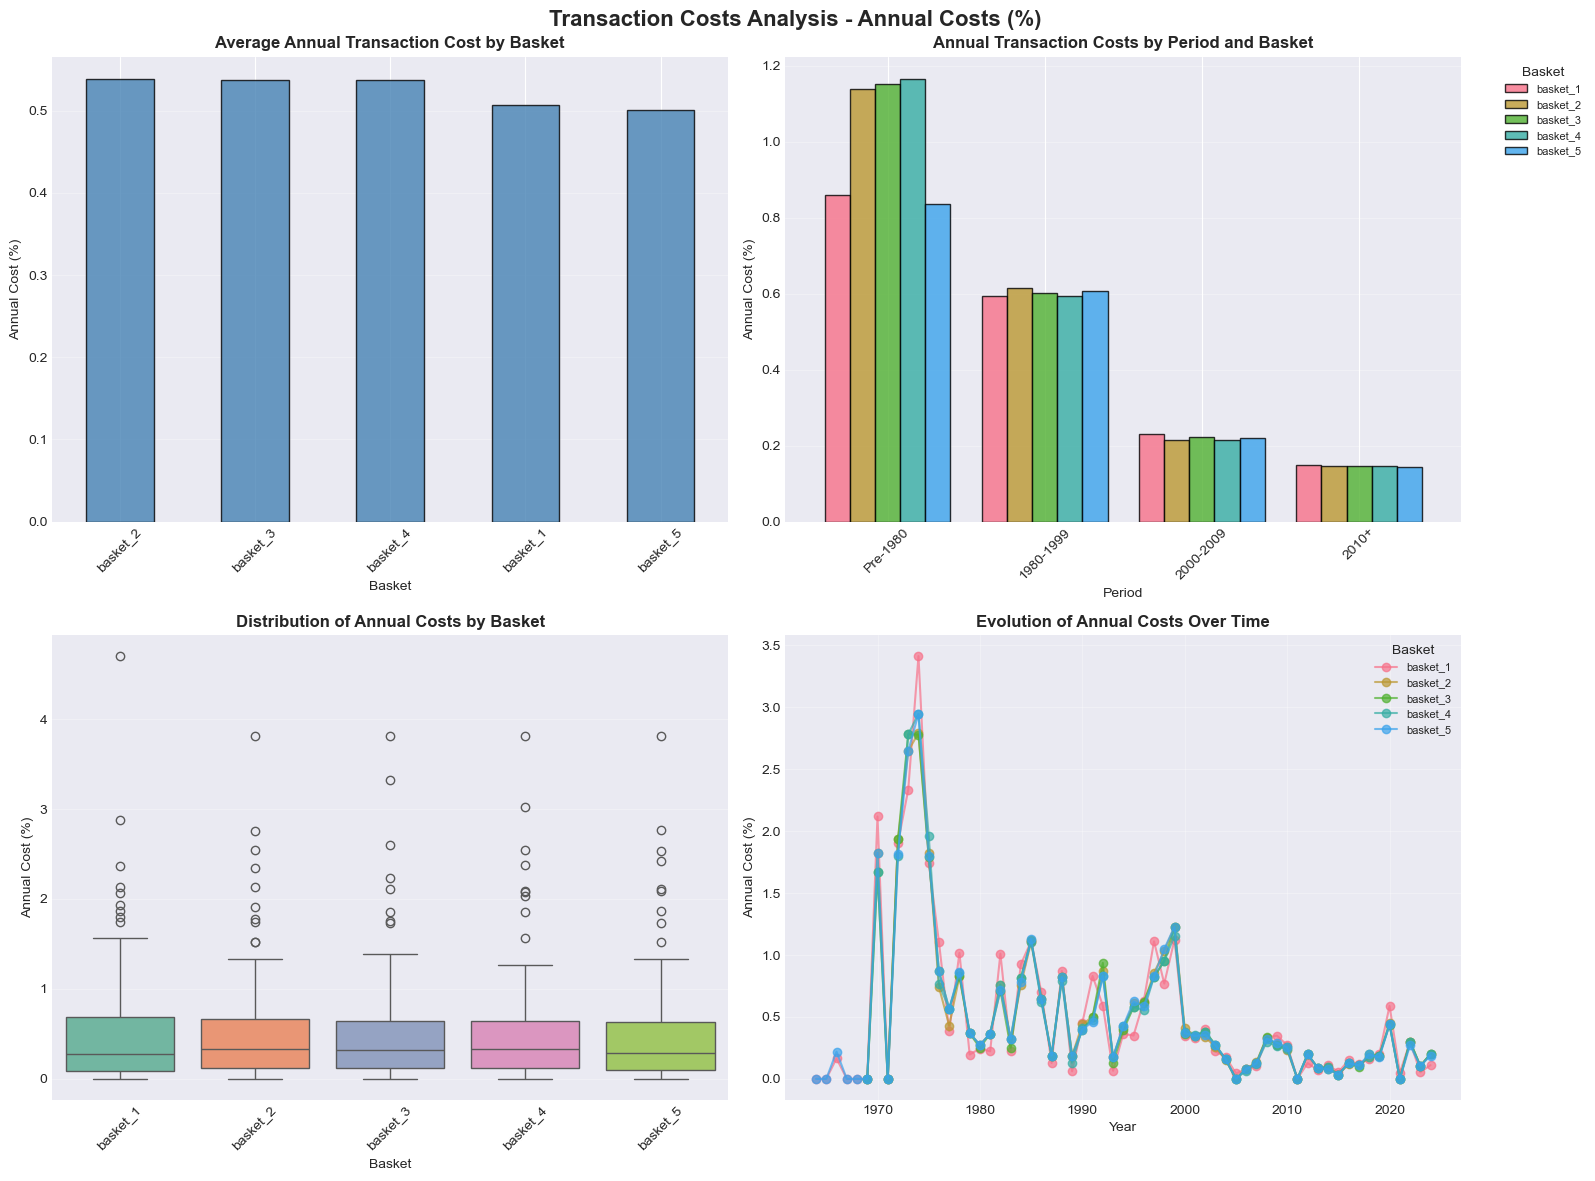

Graphiques générés avec succès!


In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Transaction Costs Analysis - Annual Costs (%)', fontsize=16, fontweight='bold')

# 1. Coûts annuels par basket (barplot)
ax1 = axes[0, 0]
basket_annual_costs.sort_values('mean_annual_cost_pct', ascending=False)['mean_annual_cost_pct'].plot(
    kind='bar', ax=ax1, color='steelblue', alpha=0.8, edgecolor='black'
)
ax1.set_title('Average Annual Transaction Cost by Basket', fontsize=12, fontweight='bold')
ax1.set_xlabel('Basket', fontsize=10)
ax1.set_ylabel('Annual Cost (%)', fontsize=10)
ax1.grid(axis='y', alpha=0.3)
ax1.tick_params(axis='x', rotation=45)

# 2. Coûts par période (grouped barplot)
ax2 = axes[0, 1]
df_pivot_plot = df_pivot.T
df_pivot_plot.plot(kind='bar', ax=ax2, width=0.8, edgecolor='black', alpha=0.8)
ax2.set_title('Annual Transaction Costs by Period and Basket', fontsize=12, fontweight='bold')
ax2.set_xlabel('Period', fontsize=10)
ax2.set_ylabel('Annual Cost (%)', fontsize=10)
ax2.legend(title='Basket', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
ax2.grid(axis='y', alpha=0.3)
ax2.tick_params(axis='x', rotation=45)

# 3. Distribution des coûts (boxplot)
ax3 = axes[1, 0]
df_june_plot = df_june.copy()
df_june_plot['cost_pct'] = df_june_plot['cost_monthly'] * 100
sns.boxplot(data=df_june_plot, x='basket', y='cost_pct', ax=ax3, palette='Set2')
ax3.set_title('Distribution of Annual Costs by Basket', fontsize=12, fontweight='bold')
ax3.set_xlabel('Basket', fontsize=10)
ax3.set_ylabel('Annual Cost (%)', fontsize=10)
ax3.grid(axis='y', alpha=0.3)
ax3.tick_params(axis='x', rotation=45)

# 4. Évolution temporelle des coûts
ax4 = axes[1, 1]
for basket in df_june['basket'].unique():
    df_basket = df_june[df_june['basket'] == basket].copy()
    df_basket_annual = df_basket.groupby(df_basket['date'].dt.year)['cost_monthly'].mean() * 100
    ax4.plot(df_basket_annual.index, df_basket_annual.values, marker='o', label=basket, alpha=0.7, linewidth=1.5)

ax4.set_title('Evolution of Annual Costs Over Time', fontsize=12, fontweight='bold')
ax4.set_xlabel('Year', fontsize=10)
ax4.set_ylabel('Annual Cost (%)', fontsize=10)
ax4.legend(title='Basket', fontsize=8, loc='upper right')
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print('Graphiques générés avec succès!')


### Stress Test

In [12]:
print('='*100)
print('STRESS TEST - HIGHER TRANSACTION COSTS')
print('='*100)

# Scénarios de stress test
stress_scenarios = {
    'Conservative (x1.5)': 1.5,      # +50% sur les coûts
    'Pessimistic (x2.0)': 2.0,       # Doublement des coûts
    'Extreme Crisis (x3.0)': 3.0,    # Triple (crise 2008-style)
    'Illiquidity Shock (x5.0)': 5.0  # Choc extrême (COVID-style)
}

# DataFrame pour stocker les résultats
stress_results = []

# Baseline (coûts actuels)
baseline_cost = df_june['cost_monthly'].mean() * 100

print(f'\nBASELINE (Frazzini et al. 2012):')
print(f'  Coût annuel moyen: {baseline_cost:.3f}%')
print(f'  Coût médian: {df_june["cost_monthly"].median() * 100:.3f}%')

# Calculer pour chaque scénario
for scenario_name, multiplier in stress_scenarios.items():
    df_stress = df_june.copy()
    df_stress['cost_stressed'] = df_stress['cost_monthly'] * multiplier
    
    # Stats par basket
    basket_stats = df_stress.groupby('basket')['cost_stressed'].mean() * 100
    
    # Stats globales
    mean_cost = df_stress['cost_stressed'].mean() * 100
    median_cost = df_stress['cost_stressed'].median() * 100
    max_cost = df_stress['cost_stressed'].max() * 100
    
    print(f'\n{scenario_name.upper()}:')
    print(f'  Coût annuel moyen: {mean_cost:.3f}%')
    print(f'  Coût médian: {median_cost:.3f}%')
    print(f'  Coût max: {max_cost:.3f}%')
    print(f'  Par basket:')
    for basket, cost in basket_stats.items():
        print(f'    {basket}: {cost:.3f}%')
    
    # Stocker pour le tableau récapitulatif
    for basket in df_stress['basket'].unique():
        stress_results.append({
            'Scenario': scenario_name,
            'Multiplier': multiplier,
            'Basket': basket,
            'Annual_Cost_pct': df_stress[df_stress['basket'] == basket]['cost_stressed'].mean() * 100
        })

# Créer un DataFrame récapitulatif
df_stress_summary = pd.DataFrame(stress_results)

# Pivot pour visualisation
df_stress_pivot = df_stress_summary.pivot_table(
    index='Basket',
    columns='Scenario',
    values='Annual_Cost_pct'
)

print('\n' + '='*100)
print('STRESS TEST SUMMARY - Annual Costs (%) by Basket and Scenario')
print('='*100)
print(df_stress_pivot.round(3))

# Calculer l'impact sur un alpha hypothétique de 8%
print('\n' + '='*100)
print('IMPACT ON NET ALPHA (assuming 8% gross alpha)')
print('='*100)

gross_alpha = 8.0
print(f'\nGross Alpha: {gross_alpha:.2f}%')
print(f'\nBaseline (Frazzini): Net Alpha = {gross_alpha - baseline_cost:.2f}%')

for scenario_name, multiplier in stress_scenarios.items():
    stressed_cost = baseline_cost * multiplier
    net_alpha = gross_alpha - stressed_cost
    alpha_reduction_pct = (stressed_cost / gross_alpha) * 100
    
    print(f'{scenario_name}: Net Alpha = {net_alpha:.2f}% (reduction: {alpha_reduction_pct:.1f}%)')

print('\n' + '='*100)


STRESS TEST - HIGHER TRANSACTION COSTS

BASELINE (Frazzini et al. 2012):
  Coût annuel moyen: 0.524%
  Coût médian: 0.303%

CONSERVATIVE (X1.5):
  Coût annuel moyen: 0.786%
  Coût médian: 0.454%
  Coût max: 7.051%
  Par basket:
    basket_1: 0.760%
    basket_2: 0.808%
    basket_3: 0.807%
    basket_4: 0.806%
    basket_5: 0.751%

PESSIMISTIC (X2.0):
  Coût annuel moyen: 1.047%
  Coût médian: 0.606%
  Coût max: 9.401%
  Par basket:
    basket_1: 1.014%
    basket_2: 1.078%
    basket_3: 1.077%
    basket_4: 1.074%
    basket_5: 1.002%

EXTREME CRISIS (X3.0):
  Coût annuel moyen: 1.571%
  Coût médian: 0.909%
  Coût max: 14.101%
  Par basket:
    basket_1: 1.520%
    basket_2: 1.617%
    basket_3: 1.615%
    basket_4: 1.611%
    basket_5: 1.503%

ILLIQUIDITY SHOCK (X5.0):
  Coût annuel moyen: 2.618%
  Coût médian: 1.515%
  Coût max: 23.502%
  Par basket:
    basket_1: 2.534%
    basket_2: 2.695%
    basket_3: 2.692%
    basket_4: 2.686%
    basket_5: 2.504%

STRESS TEST SUMMARY - Annual

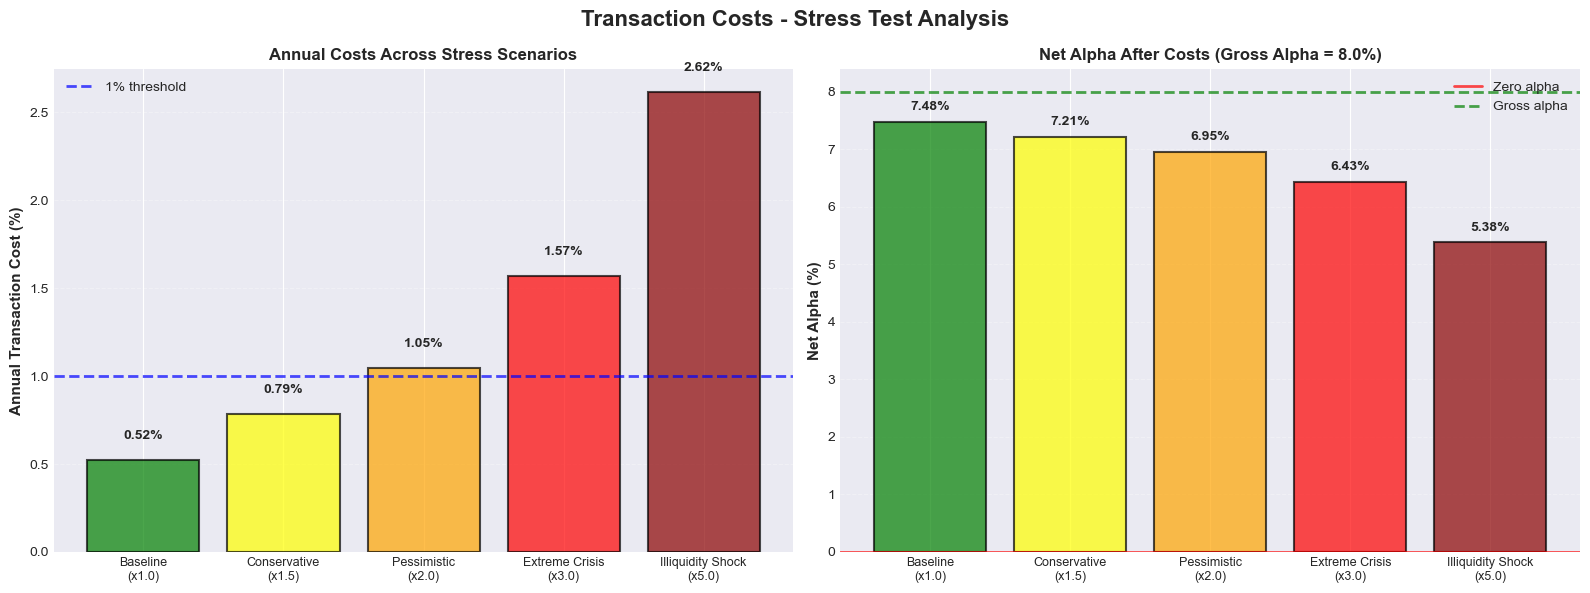


Stress test graphs generated successfully!
Baseline cost: 0.524%
Extreme scenario (x5): 2.618%


In [13]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Transaction Costs - Stress Test Analysis', fontsize=16, fontweight='bold')

# Baseline et scénarios
scenarios_list = ['Baseline\n(Frazzini)'] + list(stress_scenarios.keys())
multipliers_list = [1.0] + list(stress_scenarios.values())
costs_list = [baseline_cost] + [baseline_cost * m for m in stress_scenarios.values()]

colors = ['green', 'yellow', 'orange', 'red', 'darkred']

# 1. Barplot comparatif par scénario
ax1 = axes[0]
bars = ax1.bar(range(len(scenarios_list)), costs_list, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)

ax1.set_xticks(range(len(scenarios_list)))
ax1.set_xticklabels([f'{s.split("(")[0].strip()}\n(x{m})' for s, m in zip(scenarios_list, multipliers_list)], 
                     rotation=0, ha='center', fontsize=9)
ax1.set_ylabel('Annual Transaction Cost (%)', fontsize=11, fontweight='bold')
ax1.set_title('Annual Costs Across Stress Scenarios', fontsize=12, fontweight='bold')
ax1.grid(axis='y', alpha=0.3, linestyle='--')
ax1.axhline(y=1.0, color='blue', linestyle='--', linewidth=2, label='1% threshold', alpha=0.7)
ax1.legend(fontsize=10)

# Ajouter les valeurs sur les barres
for bar, cost in zip(bars, costs_list):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.1,
             f'{cost:.2f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

# 2. Impact sur le net alpha
ax2 = axes[1]
gross_alpha = 8.0
net_alphas = [gross_alpha - cost for cost in costs_list]

bars2 = ax2.bar(range(len(scenarios_list)), net_alphas, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)

ax2.set_xticks(range(len(scenarios_list)))
ax2.set_xticklabels([f'{s.split("(")[0].strip()}\n(x{m})' for s, m in zip(scenarios_list, multipliers_list)], 
                     rotation=0, ha='center', fontsize=9)
ax2.set_ylabel('Net Alpha (%)', fontsize=11, fontweight='bold')
ax2.set_title(f'Net Alpha After Costs (Gross Alpha = {gross_alpha}%)', fontsize=12, fontweight='bold')
ax2.grid(axis='y', alpha=0.3, linestyle='--')
ax2.axhline(y=0, color='red', linestyle='-', linewidth=2, label='Zero alpha', alpha=0.7)
ax2.axhline(y=gross_alpha, color='green', linestyle='--', linewidth=2, label='Gross alpha', alpha=0.7)
ax2.legend(fontsize=10)

# Ajouter les valeurs sur les barres
for bar, net_alpha in zip(bars2, net_alphas):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 0.15,
             f'{net_alpha:.2f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

print('\nStress test graphs generated successfully!')
print(f'Baseline cost: {baseline_cost:.3f}%')
print(f'Extreme scenario (x5): {baseline_cost * 5:.3f}%')


### Upper Layer inter basket turnover and costs

In [14]:
# ════════════════════════════════════════════════════════════════
# CELL A: Inter-Basket Turnover (Offensive ↔ Defensive) - Standalone
# ════════════════════════════════════════════════════════════════

import pandas as pd
import numpy as np

print("="*80)
print("INTER-BASKET TURNOVER ANALYSIS (INDEPENDENT)")
print("="*80)

# Load allocation matrices for baskets 2-5
allocation_files = {
    'Basket 2 (Expansion)': 'data/ml_data/baskets/allocations/basket_2_allocations.parquet',
    'Basket 3 (Rolling)': 'data/ml_data/baskets/allocations/basket_3_allocations.parquet',
    'Basket 4 (EWMA)': 'data/ml_data/baskets/allocations/basket_4_allocations.parquet',
    'Basket 5 (Kalman)': 'data/ml_data/baskets/allocations/basket_5_allocations.parquet'
}

# Calculate inter-basket switching for each basket
switches_per_basket = {}

for basket_label, filepath in allocation_files.items():
    df_alloc = pd.read_parquet(filepath)

    # Extract HIGH_BETA columns (Offensive classification)
    high_cols = [col for col in df_alloc.columns if col[0] == 'HIGH_BETA']
    signal_names = [col[1] for col in high_cols]
    num_signals = len(signal_names)

    # Create binary allocation: 1 = Offensive (HIGH), 0 = Defensive (LOW)
    signal_allocation = pd.DataFrame(index=df_alloc.index)
    for signal_name in signal_names:
        signal_allocation[signal_name] = df_alloc[('HIGH_BETA', signal_name)].astype(int)

    # Calculate switches: |allocation[t] - allocation[t-1]|
    switches = (signal_allocation - signal_allocation.shift(1)).abs()

    # Monthly turnover = (sum of switches) / number of signals
    monthly_turnover = switches.sum(axis=1) / num_signals

    switches_per_basket[basket_label] = monthly_turnover

    print(f"✓ {basket_label:25s}: {len(df_alloc)} months, {num_signals} signals")

# Combine all baskets
df_inter_turnover = []
for basket_label, turnover_series in switches_per_basket.items():
    df_temp = pd.DataFrame({
        'date': turnover_series.index,
        'basket': basket_label,
        'turnover_inter': turnover_series.values
    })
    df_inter_turnover.append(df_temp)

df_inter_turnover = pd.concat(df_inter_turnover, ignore_index=True)

# Apply Frazzini time-varying costs
df_inter_turnover['cost_bps'] = df_inter_turnover['date'].apply(get_frazzini_cost_bps)
df_inter_turnover['cost_monthly'] = 2 * df_inter_turnover['turnover_inter'] * df_inter_turnover['cost_bps'] / 10000.0
df_inter_turnover['cost_annual'] = df_inter_turnover['cost_monthly'] * 12

# Statistics
inter_tc_mean = df_inter_turnover['cost_annual'].mean() * 100
inter_turnover_mean = df_inter_turnover['turnover_inter'].mean() * 100

print("\n" + "="*80)
print("RESULTS: Inter-Basket Switching Costs")
print("="*80)
print(f"\nGlobal Statistics:")
print(f"  Mean Monthly Turnover: {inter_turnover_mean:.4f}%")
print(f"  Mean Annual Cost:      {inter_tc_mean:.4f}%")

print(f"\nBy Basket:")
for basket_name in sorted(df_inter_turnover['basket'].unique()):
    subset = df_inter_turnover[df_inter_turnover['basket'] == basket_name]
    mean_annual = subset['cost_annual'].mean() * 100
    mean_turnover = subset['turnover_inter'].mean() * 100
    print(f"  {basket_name:25s}: {mean_annual:.4f}% (Turnover: {mean_turnover:.2f}%)")

print("="*80)


INTER-BASKET TURNOVER ANALYSIS (INDEPENDENT)
✓ Basket 2 (Expansion)     : 672 months, 25 signals
✓ Basket 3 (Rolling)       : 672 months, 25 signals
✓ Basket 4 (EWMA)          : 672 months, 25 signals
✓ Basket 5 (Kalman)        : 731 months, 25 signals

RESULTS: Inter-Basket Switching Costs

Global Statistics:
  Mean Monthly Turnover: 2.8482%
  Mean Annual Cost:      0.1650%

By Basket:
  Basket 2 (Expansion)     : 0.0394% (Turnover: 0.40%)
  Basket 3 (Rolling)       : 0.1650% (Turnover: 2.93%)
  Basket 4 (EWMA)          : 0.2854% (Turnover: 5.15%)
  Basket 5 (Kalman)        : 0.1697% (Turnover: 2.90%)


In [15]:
# ════════════════════════════════════════════════════════════════
# CELL B: Total Transaction Costs (2 Layers) - DETAILED BY BASKET
# ════════════════════════════════════════════════════════════════

print("="*80)
print("TRANSACTION COSTS - 2 LAYERS ANALYSIS (DETAILED BY BASKET)")
print("="*80)

# ════════════════════════════════════════════════════════════════
# Layer 1: Stock-Level TC (from existing df_turnover_all)
# ════════════════════════════════════════════════════════════════

stock_tc_by_basket = (
    df_turnover_all[df_turnover_all['is_rebalance_month']]
    .groupby('basket')['cost_monthly']
    .mean() * 100
)

print("\n1. STOCK-LEVEL TC (Annual June Rebalancing)")
print("-" * 80)
for basket in sorted(stock_tc_by_basket.index):
    print(f"  {basket:12s}: {stock_tc_by_basket[basket]:.4f}%")

stock_tc_mean = stock_tc_by_basket.mean()
print(f"\n  → Global Mean: {stock_tc_mean:.4f}%")

# ════════════════════════════════════════════════════════════════
# Layer 2: Inter-Basket TC (from Cell A above)
# ════════════════════════════════════════════════════════════════

inter_tc_by_basket = (
    df_inter_turnover
    .groupby('basket')['cost_annual']
    .mean() * 100
)

print("\n2. INTER-BASKET TC (Offensive ↔ Defensive Switches)")
print("-" * 80)
for basket in sorted(inter_tc_by_basket.index):
    print(f"  {basket:25s}: {inter_tc_by_basket[basket]:.4f}%")

inter_tc_mean = inter_tc_by_basket.mean()
print(f"\n  → Global Mean: {inter_tc_mean:.4f}%")

# ════════════════════════════════════════════════════════════════
# TOTAL TC by Basket
# ════════════════════════════════════════════════════════════════

print("\n" + "="*80)
print("TOTAL TRANSACTION COSTS (Stock + Inter-Basket)")
print("="*80)

# Map basket names
basket_mapping = {
    'basket_1': 'Basket 1 (Economic)',
    'basket_2': 'Basket 2 (Expansion)',
    'basket_3': 'Basket 3 (Rolling)',
    'basket_4': 'Basket 4 (EWMA)',
    'basket_5': 'Basket 5 (Kalman)'
}

results = []
for basket_id in ['basket_1', 'basket_2', 'basket_3', 'basket_4', 'basket_5']:
    stock = stock_tc_by_basket.get(basket_id, 0.0)
    
    # Map basket name for inter_tc lookup
    basket_label = basket_mapping[basket_id]
    inter = inter_tc_by_basket.get(basket_label, 0.0)
    
    total = stock + inter
    
    results.append({
        'Basket': basket_id,
        'Stock-Level (%)': stock,
        'Inter-Basket (%)': inter,
        'Total (%)': total
    })

df_results = pd.DataFrame(results)

print("\n" + df_results.to_string(index=False))

# Global summary
total_tc_mean = df_results['Total (%)'].mean()
print("\n" + "="*80)
print(f"GLOBAL MEAN TOTAL TC: {total_tc_mean:.4f}%")
print("="*80)

# Interpretation
allocation_pct = (inter_tc_mean / total_tc_mean) * 100
stock_pct = (stock_tc_mean / total_tc_mean) * 100

print(f"\nBreakdown:")
print(f"  Stock-level dominates:   {stock_pct:.1f}% of total")
print(f"  Allocation-level:        {allocation_pct:.1f}% of total")

if inter_tc_mean < 0.1:
    print(f"\n✓ Inter-basket TC ({inter_tc_mean:.4f}%) is NEGLIGIBLE")
    print("✓ 'Frictionless allocation' assumption VALIDATED")
elif inter_tc_mean < 0.5:
    print(f"\n! Inter-basket TC ({inter_tc_mean:.4f}%) is LOW but measurable")
    print("! Consider mentioning in sensitivity analysis")
else:
    print(f"\n✗ Inter-basket TC ({inter_tc_mean:.4f}%) is MATERIAL")
    print("✗ Should report net-of-TC returns")

print("="*80)


TRANSACTION COSTS - 2 LAYERS ANALYSIS (DETAILED BY BASKET)

1. STOCK-LEVEL TC (Annual June Rebalancing)
--------------------------------------------------------------------------------
  basket_1    : 0.5068%
  basket_2    : 0.5389%
  basket_3    : 0.5383%
  basket_4    : 0.5371%
  basket_5    : 0.5009%

  → Global Mean: 0.5244%

2. INTER-BASKET TC (Offensive ↔ Defensive Switches)
--------------------------------------------------------------------------------
  Basket 2 (Expansion)     : 0.0394%
  Basket 3 (Rolling)       : 0.1650%
  Basket 4 (EWMA)          : 0.2854%
  Basket 5 (Kalman)        : 0.1697%

  → Global Mean: 0.1649%

TOTAL TRANSACTION COSTS (Stock + Inter-Basket)

  Basket  Stock-Level (%)  Inter-Basket (%)  Total (%)
basket_1         0.506797          0.000000   0.506797
basket_2         0.538944          0.039429   0.578372
basket_3         0.538302          0.165000   0.703302
basket_4         0.537135          0.285429   0.822563
basket_5         0.500850          0.

# Cell 9: Export Monthly Transaction Costs

Save final dataset for 11_1_CLEAN integration.

In [16]:
# output_file = OUTPUT_DIR / 'transaction_costs_monthly.parquet'

# df_turnover_all.to_parquet(output_file, index=False)

# print(f'Transaction costs exported to: {output_file}')
# print(f'File size: {output_file.stat().st_size / 1024:.2f} KB')

# print('\nExported columns:')
# print(df_turnover_all.columns.tolist())

# print('\nExported data shape:')
# print(f'Rows: {df_turnover_all.shape[0]}')
# print(f'Columns: {df_turnover_all.shape[1]}')

# print('\nSummary by basket:')
# summary = df_turnover_all.groupby(['basket', 'signal']).agg({
#     'turnover_ew': ['count', 'mean', 'std'],
#     'cost_monthly': 'mean'
# }).round(6)
# print(summary)

# print('\nIntegration instructions:')
# print('1. Load transaction_costs_monthly.parquet in 11_1_CLEAN')
# print('2. Merge with portfolio returns on [date, basket, signal]')
# print('3. Subtract cost_monthly from portfolio_return')
# print('4. Costs already zero for non-June months (Fama-French convention)')
# print('5. Aggregate net returns via Equal-Weight mean across signals')

In [17]:
# ════════════════════════════════════════════════════════════════
# CELL C: Export Transaction Costs to Parquet Files
# ════════════════════════════════════════════════════════════════

import pandas as pd
from pathlib import Path

print("="*80)
print("EXPORTING TRANSACTION COSTS TO PARQUET FILES")
print("="*80)

# Create output directory
OUTPUT_DIR = Path('/Users/jey/Desktop/Quant/V2/data/ml_data/transaction_costs')
OUTPUT_DIR.mkdir(exist_ok=True, parents=True)

# ════════════════════════════════════════════════════════════════
# File 1: Summary by Basket (Static)
# ════════════════════════════════════════════════════════════════

df_summary_export = df_results.copy()
df_summary_export['basket_name'] = df_summary_export['Basket'].map(basket_mapping)

df_summary_export = df_summary_export[[
    'Basket', 'basket_name',
    'Stock-Level (%)', 'Inter-Basket (%)', 'Total (%)'
]]

file1_path = OUTPUT_DIR / 'tc_summary_by_basket.parquet'
df_summary_export.to_parquet(file1_path, index=False)

print(f"\n✓ File 1: {file1_path}")
print(f"  Rows: {df_summary_export.shape[0]}")
print(f"  Columns: {df_summary_export.columns.tolist()}")
print(f"  Size: {file1_path.stat().st_size / 1024:.2f} KB")
print(f"\n{df_summary_export.to_string(index=False)}")

# ════════════════════════════════════════════════════════════════
# File 2: Time-Series Monthly (Dynamic) - AVEC STRATÉGIE
# ════════════════════════════════════════════════════════════════

# ──────────────────────────────────────────────────────────────
# STOCK-LEVEL TC: GARDER LA DIMENSION STRATEGY (signal)
# ──────────────────────────────────────────────────────────────

df_stock_timeseries = df_turnover_all[['date', 'basket', 'signal', 'cost_monthly']].copy()
df_stock_timeseries.rename(columns={
    'cost_monthly': 'stock_tc_monthly',
    'signal': 'strategy'  # ← RENOMMER pour clarté
}, inplace=True)

# Convertir en %
df_stock_timeseries['stock_tc_pct'] = df_stock_timeseries['stock_tc_monthly'] * 100

# ──────────────────────────────────────────────────────────────
# INTER-BASKET TC: MAPPER PAR STRATÉGIE
# ──────────────────────────────────────────────────────────────

df_inter_timeseries = df_inter_turnover[['date', 'basket', 'cost_monthly']].copy()
df_inter_timeseries.rename(columns={'cost_monthly': 'inter_tc_monthly'}, inplace=True)

# Map basket names to IDs
basket_name_to_id = {v: k for k, v in basket_mapping.items()}
df_inter_timeseries['basket_id'] = df_inter_timeseries['basket'].map(basket_name_to_id)

# Convertir en %
df_inter_timeseries['inter_tc_pct'] = df_inter_timeseries['inter_tc_monthly'] * 100

# ──────────────────────────────────────────────────────────────
# CRÉER MAPPING STRATEGY → INTER TC
# ──────────────────────────────────────────────────────────────

# Pour chaque (date, basket), on doit mapper inter_tc aux différentes stratégies:
# - Offensive/High_Beta: peut avoir inter_tc si switch
# - Defensive/Low_Beta: peut avoir inter_tc si switch
# Pour simplifier: on duplique inter_tc pour toutes les stratégies du basket

# Liste des stratégies par basket
strategy_mapping = {
    'basket_1': ['Offensive', 'Defensive'],
    'basket_2': ['High_Beta', 'Low_Beta'],
    'basket_3': ['High_Beta', 'Low_Beta'],
    'basket_4': ['High_Beta', 'Low_Beta'],
    'basket_5': ['High_Beta', 'Low_Beta']
}

# Expand inter_tc pour toutes les stratégies
df_inter_expanded = []
for _, row in df_inter_timeseries.iterrows():
    basket_id = row['basket_id']
    strategies = strategy_mapping.get(basket_id, [])
    
    for strategy in strategies:
        df_inter_expanded.append({
            'date': row['date'],
            'basket': basket_id,
            'strategy': strategy,
            'inter_tc_pct': row['inter_tc_pct']
        })

df_inter_expanded = pd.DataFrame(df_inter_expanded)

# ──────────────────────────────────────────────────────────────
# MERGE STOCK + INTER
# ──────────────────────────────────────────────────────────────

df_timeseries_merged = df_stock_timeseries.merge(
    df_inter_expanded[['date', 'basket', 'strategy', 'inter_tc_pct']],
    on=['date', 'basket', 'strategy'],
    how='left'
)

# Fill missing inter_tc with 0
df_timeseries_merged['inter_tc_pct'] = df_timeseries_merged['inter_tc_pct'].fillna(0.0)

# Calculate total TC
df_timeseries_merged['total_tc_pct'] = (
    df_timeseries_merged['stock_tc_pct'] + 
    df_timeseries_merged['inter_tc_pct']
)

# Final export columns
df_timeseries_final = df_timeseries_merged[[
    'date', 'basket', 'strategy',
    'stock_tc_pct', 'inter_tc_pct', 'total_tc_pct'
]].copy()

file2_path = OUTPUT_DIR / 'tc_timeseries_monthly.parquet'
df_timeseries_final.to_parquet(file2_path, index=False)

print(f"\n✓ File 2: {file2_path}")
print(f"  Rows: {df_timeseries_final.shape[0]}")
print(f"  Columns: {df_timeseries_final.columns.tolist()}")
print(f"  Size: {file2_path.stat().st_size / 1024:.2f} KB")
print(f"  Date range: {df_timeseries_final['date'].min()} to {df_timeseries_final['date'].max()}")

# Sample output
print(f"\n  Sample (basket_1, first 10 rows):")
print(df_timeseries_final[df_timeseries_final['basket'] == 'basket_1'].head(10).to_string(index=False))

print(f"\n  Sample (basket_2, June only, first 10):")
june_sample = df_timeseries_final[
    (df_timeseries_final['basket'] == 'basket_2') & 
    (df_timeseries_final['date'].dt.month == 6)
].head(10)
print(june_sample.to_string(index=False))

print(f"\n  Stats by basket and strategy:")
print(df_timeseries_final.groupby(['basket', 'strategy'])[['stock_tc_pct', 'inter_tc_pct', 'total_tc_pct']].mean())

# ════════════════════════════════════════════════════════════════
# Usage Instructions for 11_1
# ════════════════════════════════════════════════════════════════

print("\n" + "="*80)
print("USAGE INSTRUCTIONS FOR NOTEBOOK 11_1")
print("="*80)

print("""
# Load transaction costs
tc_timeseries = pd.read_parquet('data/transaction_costs/tc_timeseries_monthly.parquet')

# Merge with portfolio returns on [date, basket, strategy]
df_net = df_gross.merge(
    tc_timeseries[['date', 'basket', 'strategy', 'total_tc_pct']], 
    on=['date', 'basket', 'strategy'], 
    how='left'
)

# Apply TC
df_net['return_net'] = df_net['return_gross'] - (df_net['total_tc_pct'] / 100)

# Options:
# - Use total_tc_pct for full costs (stock + inter)
# - Use stock_tc_pct for baseline (Frazzini convention)
# - Use inter_tc_pct separately for sensitivity analysis
""")

print("="*80)
print("EXPORT COMPLETE")
print("="*80)


EXPORTING TRANSACTION COSTS TO PARQUET FILES

✓ File 1: /Users/jey/Desktop/Quant/V2/data/ml_data/transaction_costs/tc_summary_by_basket.parquet
  Rows: 5
  Columns: ['Basket', 'basket_name', 'Stock-Level (%)', 'Inter-Basket (%)', 'Total (%)']
  Size: 4.10 KB

  Basket          basket_name  Stock-Level (%)  Inter-Basket (%)  Total (%)
basket_1  Basket 1 (Economic)         0.506797          0.000000   0.506797
basket_2 Basket 2 (Expansion)         0.538944          0.039429   0.578372
basket_3   Basket 3 (Rolling)         0.538302          0.165000   0.703302
basket_4      Basket 4 (EWMA)         0.537135          0.285429   0.822563
basket_5    Basket 5 (Kalman)         0.500850          0.169674   0.670525

✓ File 2: /Users/jey/Desktop/Quant/V2/data/ml_data/transaction_costs/tc_timeseries_monthly.parquet
  Rows: 6970
  Columns: ['date', 'basket', 'strategy', 'stock_tc_pct', 'inter_tc_pct', 'total_tc_pct']
  Size: 31.57 KB
  Date range: 1963-07-31 00:00:00 to 2024-12-31 00:00:00

  Samp

EXPLORING EXPORTED TRANSACTION COSTS

✓ Summary loaded: 5 baskets
✓ Time-series loaded: 6970 observations


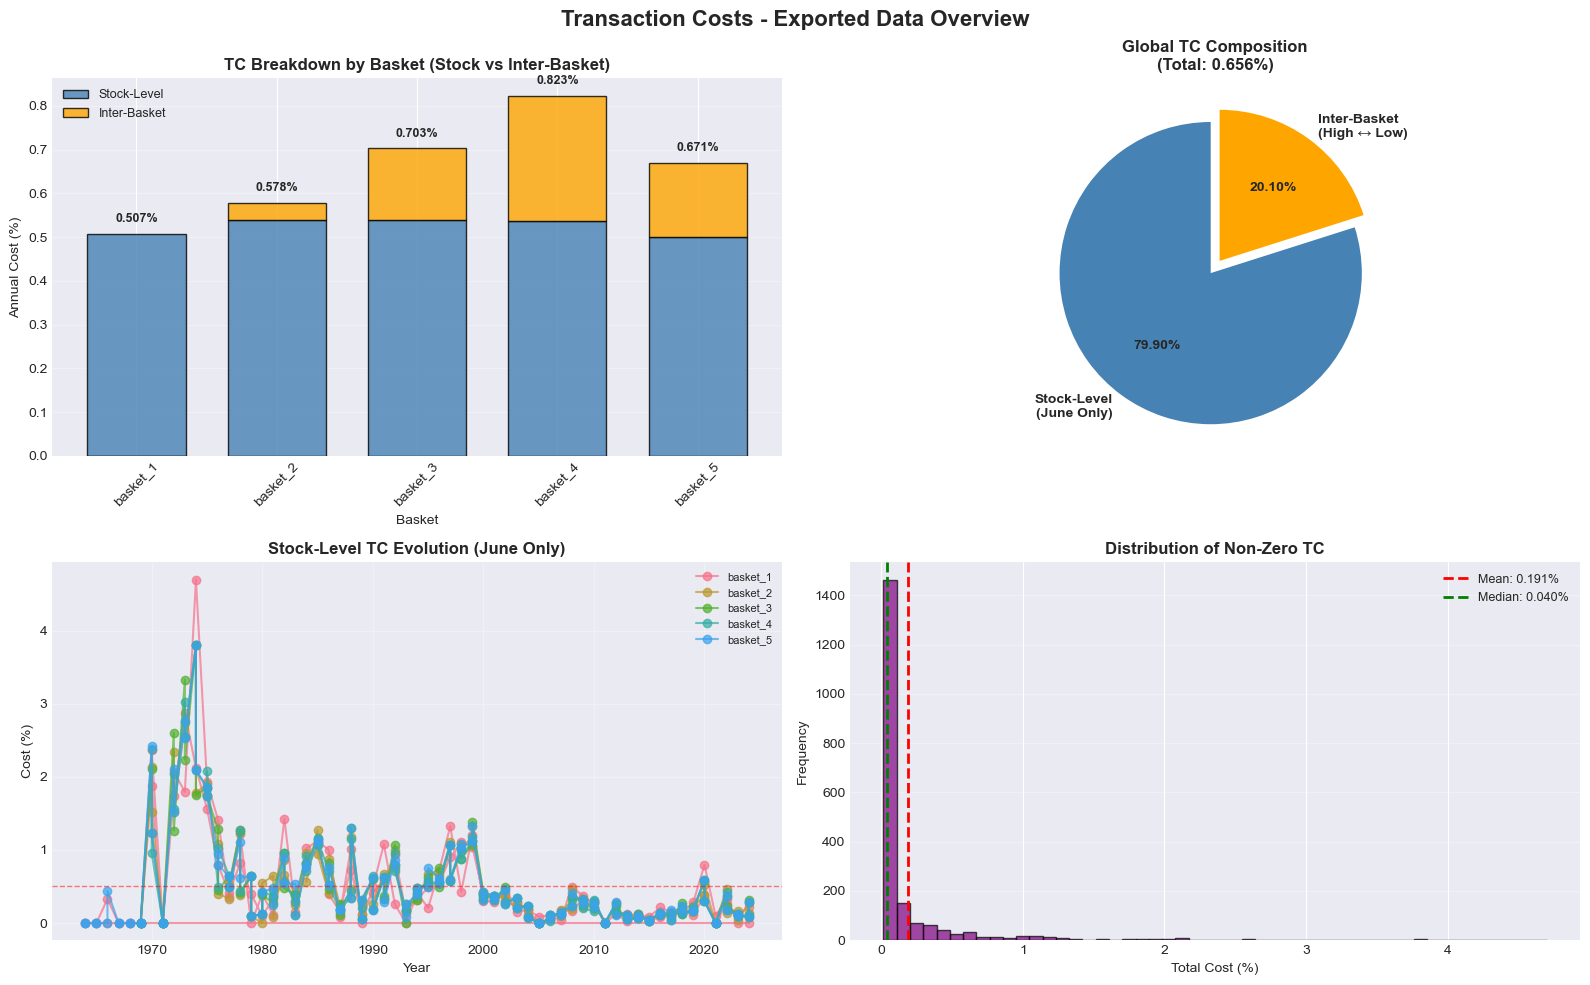

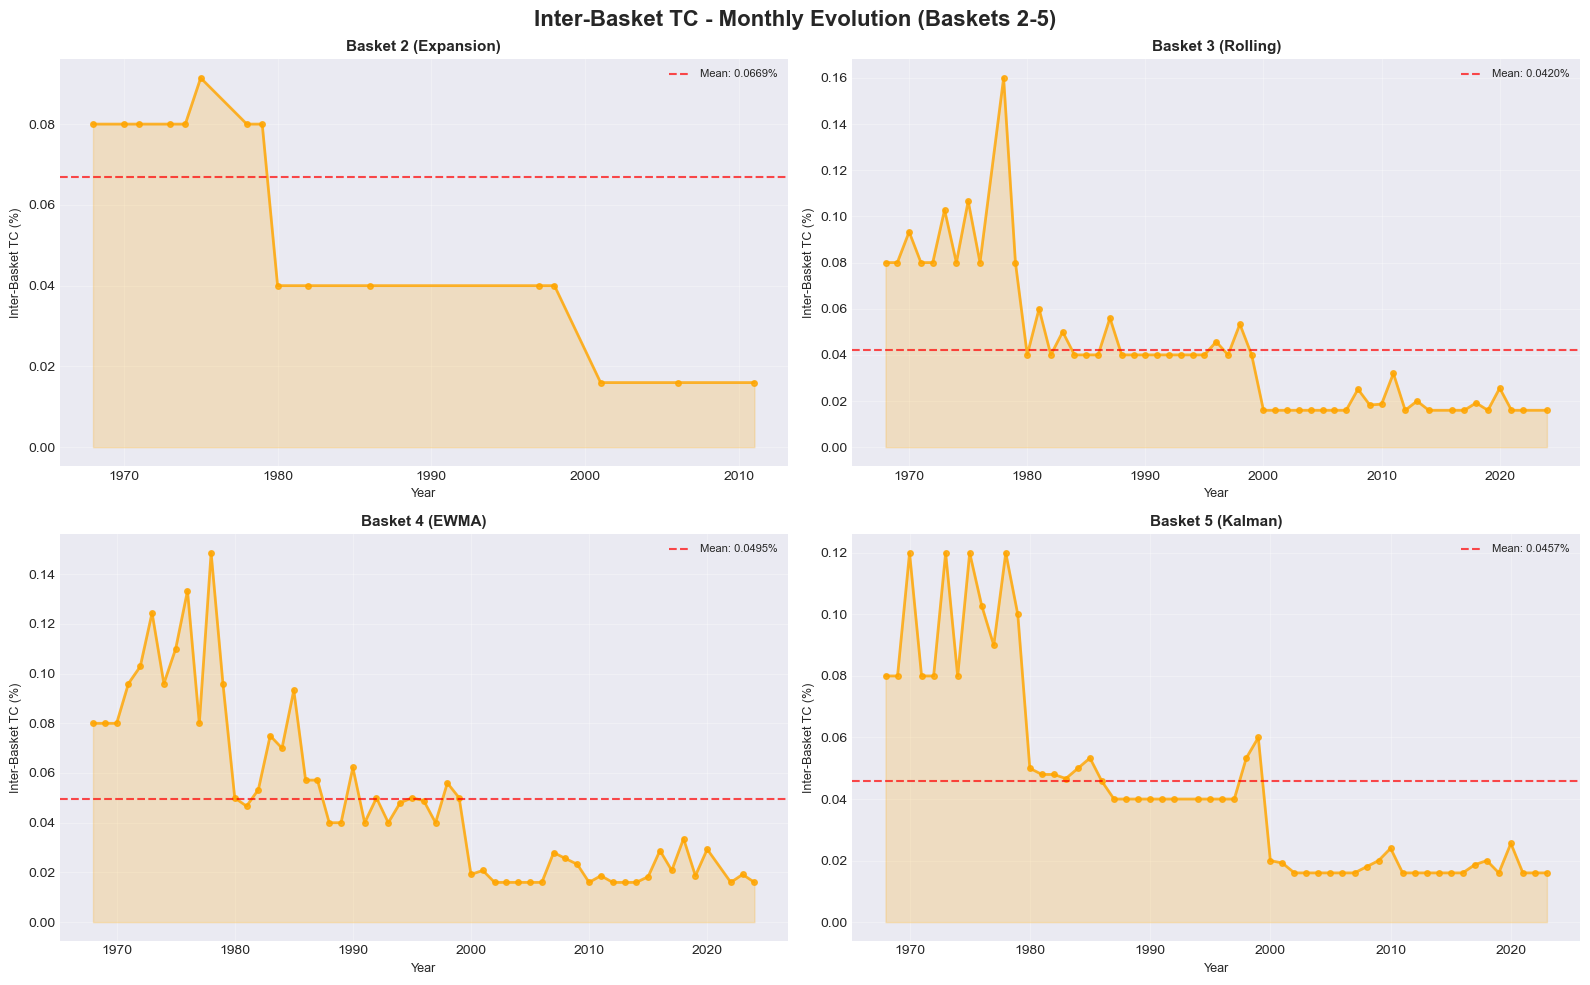


SUMMARY STATISTICS

1. TC Summary by Basket:
  Basket          basket_name  Stock-Level (%)  Inter-Basket (%)  Total (%)
basket_1  Basket 1 (Economic)         0.506797          0.000000   0.506797
basket_2 Basket 2 (Expansion)         0.538944          0.039429   0.578372
basket_3   Basket 3 (Rolling)         0.538302          0.165000   0.703302
basket_4      Basket 4 (EWMA)         0.537135          0.285429   0.822563
basket_5    Basket 5 (Kalman)         0.500850          0.169674   0.670525

2. Time-Series Statistics:
   Total observations: 6,970
   Date range: 1963-07-31 00:00:00 → 2024-12-31 00:00:00
   Unique baskets: 5
   Non-zero stock TC: 507 (7.27%)
   Non-zero inter TC: 1,604 (23.01%)
   Non-zero total TC: 1,983 (28.45%)

3. Monthly Statistics (All baskets combined):
              count    mean     std  min  25%     50%    75%     max
stock_tc_pct  738.0  0.0413  0.2241  0.0  0.0  0.0000  0.000  2.9767
inter_tc_pct  738.0  0.0102  0.0163  0.0  0.0  0.0032  0.016  0.1920
t

In [18]:
# ════════════════════════════════════════════════════════════════
# CELL D: Visualization - Explore Exported Transaction Costs
# ════════════════════════════════════════════════════════════════

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

print("="*80)
print("EXPLORING EXPORTED TRANSACTION COSTS")
print("="*80)

# ════════════════════════════════════════════════════════════════
# Load Exported Files
# ════════════════════════════════════════════════════════════════

tc_summary = pd.read_parquet('data/ml_data/transaction_costs/tc_summary_by_basket.parquet')
tc_timeseries = pd.read_parquet('data/ml_data/transaction_costs/tc_timeseries_monthly.parquet')

print(f"\n✓ Summary loaded: {tc_summary.shape[0]} baskets")
print(f"✓ Time-series loaded: {tc_timeseries.shape[0]} observations")

# ════════════════════════════════════════════════════════════════
# Figure 1: Summary Overview (4 panels)
# ════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Transaction Costs - Exported Data Overview', fontsize=16, fontweight='bold')

# Panel 1: Summary by Basket (Stacked Bar)
ax1 = axes[0, 0]
tc_summary_plot = tc_summary.set_index('Basket')
tc_summary_plot[['Stock-Level (%)', 'Inter-Basket (%)']].plot(
    kind='bar', stacked=True, ax=ax1, 
    color=['steelblue', 'orange'], 
    alpha=0.8, edgecolor='black', width=0.7
)
ax1.set_title('TC Breakdown by Basket (Stock vs Inter-Basket)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Basket', fontsize=10)
ax1.set_ylabel('Annual Cost (%)', fontsize=10)
ax1.legend(['Stock-Level', 'Inter-Basket'], fontsize=9, loc='upper left')
ax1.grid(axis='y', alpha=0.3)
ax1.tick_params(axis='x', rotation=45)

# Add total values on top
for i, (idx, row) in enumerate(tc_summary.iterrows()):
    total = row['Total (%)']
    ax1.text(i, total + 0.02, f'{total:.3f}%', 
             ha='center', va='bottom', fontsize=9, fontweight='bold')

# Panel 2: Pie Chart - TC Composition (Global)
ax2 = axes[0, 1]
global_stock = tc_summary['Stock-Level (%)'].mean()
global_inter = tc_summary['Inter-Basket (%)'].mean()

wedges, texts, autotexts = ax2.pie(
    [global_stock, global_inter],
    labels=['Stock-Level\n(June Only)', 'Inter-Basket\n(High ↔ Low)'],
    autopct='%1.2f%%',
    colors=['steelblue', 'orange'],
    startangle=90,
    explode=(0.05, 0.05),
    textprops={'fontsize': 10, 'fontweight': 'bold'}
)
ax2.set_title(f'Global TC Composition\n(Total: {global_stock + global_inter:.3f}%)', 
              fontsize=12, fontweight='bold')

# Panel 3: Time-Series - Stock-Level TC (June only)
ax3 = axes[1, 0]
tc_june = tc_timeseries[tc_timeseries['date'].dt.month == 6].copy()
tc_june['year'] = tc_june['date'].dt.year

for basket in tc_summary['Basket'].values:
    subset = tc_june[tc_june['basket'] == basket]
    if len(subset) > 0:
        ax3.plot(subset['year'], subset['stock_tc_pct'], 
                marker='o', label=basket, alpha=0.7, linewidth=1.5)

ax3.set_title('Stock-Level TC Evolution (June Only)', fontsize=12, fontweight='bold')
ax3.set_xlabel('Year', fontsize=10)
ax3.set_ylabel('Cost (%)', fontsize=10)
ax3.legend(fontsize=8, loc='upper right')
ax3.grid(True, alpha=0.3)
ax3.axhline(y=0.5, color='red', linestyle='--', linewidth=1, alpha=0.5, label='0.5% threshold')

# Panel 4: Histogram - Distribution of Non-Zero Costs
ax4 = axes[1, 1]
tc_nonzero = tc_timeseries[tc_timeseries['total_tc_pct'] > 0]['total_tc_pct']

ax4.hist(tc_nonzero, bins=50, color='purple', alpha=0.7, edgecolor='black')
ax4.axvline(tc_nonzero.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {tc_nonzero.mean():.3f}%')
ax4.axvline(tc_nonzero.median(), color='green', linestyle='--', linewidth=2, label=f'Median: {tc_nonzero.median():.3f}%')
ax4.set_title('Distribution of Non-Zero TC', fontsize=12, fontweight='bold')
ax4.set_xlabel('Total Cost (%)', fontsize=10)
ax4.set_ylabel('Frequency', fontsize=10)
ax4.legend(fontsize=9)
ax4.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# ════════════════════════════════════════════════════════════════
# Figure 2: Monthly Inter-Basket TC (Detailed)
# ════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Inter-Basket TC - Monthly Evolution (Baskets 2-5)', fontsize=16, fontweight='bold')

baskets_beta = ['basket_2', 'basket_3', 'basket_4', 'basket_5']
basket_labels = {
    'basket_2': 'Basket 2 (Expansion)',
    'basket_3': 'Basket 3 (Rolling)',
    'basket_4': 'Basket 4 (EWMA)',
    'basket_5': 'Basket 5 (Kalman)'
}

for i, basket_id in enumerate(baskets_beta):
    ax = axes[i // 2, i % 2]
    
    subset = tc_timeseries[tc_timeseries['basket'] == basket_id].copy()
    subset = subset[subset['inter_tc_pct'] > 0]  # Only non-zero
    
    if len(subset) > 0:
        subset['year'] = subset['date'].dt.year
        annual_avg = subset.groupby('year')['inter_tc_pct'].mean()
        
        ax.plot(annual_avg.index, annual_avg.values, 
                marker='o', color='orange', linewidth=2, markersize=4, alpha=0.8)
        ax.fill_between(annual_avg.index, 0, annual_avg.values, alpha=0.2, color='orange')
        
        mean_val = subset['inter_tc_pct'].mean()
        ax.axhline(y=mean_val, color='red', linestyle='--', linewidth=1.5, 
                   label=f'Mean: {mean_val:.4f}%', alpha=0.7)
        
        ax.set_title(basket_labels[basket_id], fontsize=11, fontweight='bold')
        ax.set_xlabel('Year', fontsize=9)
        ax.set_ylabel('Inter-Basket TC (%)', fontsize=9)
        ax.legend(fontsize=8, loc='upper right')
        ax.grid(True, alpha=0.3)
    else:
        ax.text(0.5, 0.5, 'No Data', ha='center', va='center', transform=ax.transAxes)

plt.tight_layout()
plt.show()

# ════════════════════════════════════════════════════════════════
# Statistics Tables
# ════════════════════════════════════════════════════════════════

print("\n" + "="*80)
print("SUMMARY STATISTICS")
print("="*80)

print("\n1. TC Summary by Basket:")
print(tc_summary.to_string(index=False))

print("\n2. Time-Series Statistics:")
print(f"   Total observations: {tc_timeseries.shape[0]:,}")
print(f"   Date range: {tc_timeseries['date'].min()} → {tc_timeseries['date'].max()}")
print(f"   Unique baskets: {tc_timeseries['basket'].nunique()}")
print(f"   Non-zero stock TC: {(tc_timeseries['stock_tc_pct'] > 0).sum():,} ({(tc_timeseries['stock_tc_pct'] > 0).sum() / len(tc_timeseries) * 100:.2f}%)")
print(f"   Non-zero inter TC: {(tc_timeseries['inter_tc_pct'] > 0).sum():,} ({(tc_timeseries['inter_tc_pct'] > 0).sum() / len(tc_timeseries) * 100:.2f}%)")
print(f"   Non-zero total TC: {(tc_timeseries['total_tc_pct'] > 0).sum():,} ({(tc_timeseries['total_tc_pct'] > 0).sum() / len(tc_timeseries) * 100:.2f}%)")

print("\n3. Monthly Statistics (All baskets combined):")
monthly_stats = tc_timeseries.groupby(tc_timeseries['date'].dt.to_period('M')).agg({
    'stock_tc_pct': 'mean',
    'inter_tc_pct': 'mean',
    'total_tc_pct': 'mean'
}).describe()
print(monthly_stats.T.round(4))

print("\n4. Annual Statistics (June only):")
tc_june_stats = tc_june.groupby('year').agg({
    'stock_tc_pct': 'mean',
    'inter_tc_pct': 'mean',
    'total_tc_pct': 'mean'
}).describe()
print(tc_june_stats.T.round(4))

print("\n" + "="*80)
print("READY FOR USE IN NOTEBOOK 11_1")
print("="*80)

print("""
Next Steps:
1. Load tc_timeseries in notebook 11_1
2. Merge with portfolio returns on [date, basket]
3. Subtract total_tc_pct / 100 from gross returns
4. Compare baseline (stock-only) vs full (stock + inter)
""")
